In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
dist_matrix = np.loadtxt('../../data/bn_distances/distances_walklen_purge.csv',
          delimiter = ',')

In [26]:
#dist_matrix[dist_matrix==np.inf] = 0.25

# Flatten out
X = []
for r in range(99):
    X += list(dist_matrix[r,r+1:])

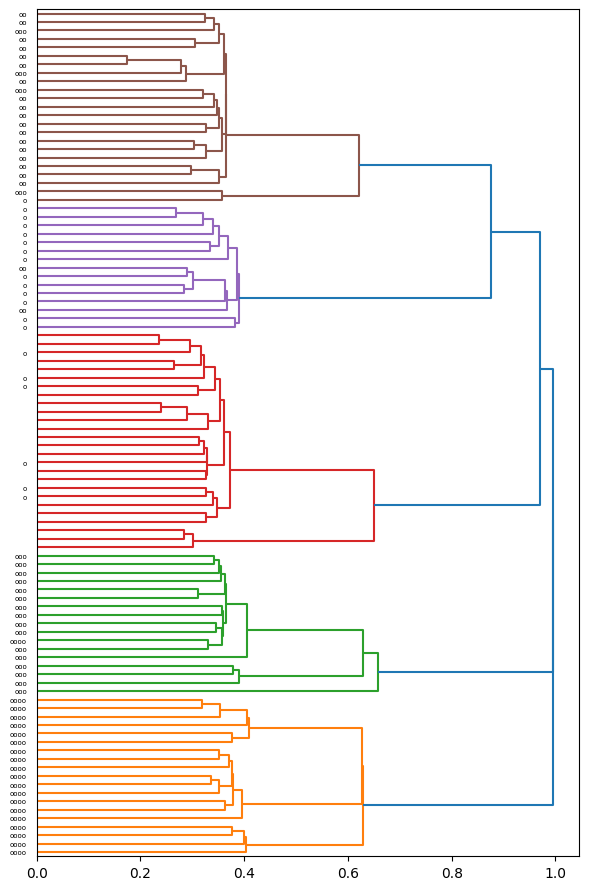

In [27]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

network_labels = [str(int(i/20)*'o') for i in range(100)]

Z = linkage(X, 'single')
fig = plt.figure(figsize=(7, 11))
dn = dendrogram(Z,
               labels = network_labels,
               orientation = 'right', color_threshold = 0.8)
#plt.savefig('../figures/dendrogram_ripsmax_original.png', bbox_inches='tight', dpi=400)

In [28]:
hole_labels = [int(i/20) for i in range(100)]
pred_clust = fcluster(Z, 5, criterion='maxclust')
pred_holes = np.zeros(100)

# Identifying classes
id_clust = []
for i in range(5):
    values, counts = np.unique(pred_clust[20*i:20*(i+1)], return_counts=True)
    id_clust.append(values[np.argmax(counts)])                    
    #for i in range(5):
    pred_holes[pred_clust == id_clust[i]] = i

#id_clust
print(f"Overall accuracy: {sum(pred_holes == hole_labels)}%")

Overall accuracy: 86%


In [29]:
## Confusion matrix
confusion = np.zeros((5,5))
for real in range(5):
    for pred in range(5):
        confusion[pred,real] = 20-sum(abs(pred_holes[real*20:(real+1)*20]-pred)>0.1)

Text(0, 0.5, 'Predicted')

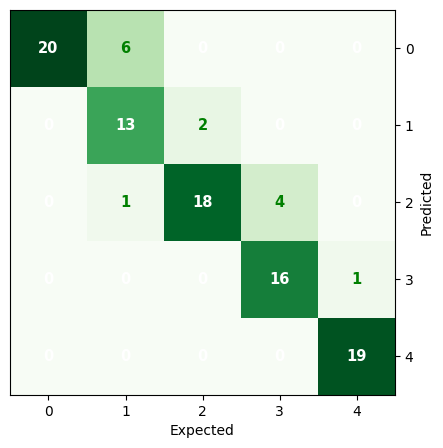

In [30]:
import matplotlib as mpl

plt.figure(figsize=(5,5))
plt.gca().yaxis.set_ticks_position('right')
plt.gca().yaxis.set_label_position('right')
plt.imshow(confusion, cmap='Greens')

for i in range(5):
    for j in range(5):
        c = 'w'
        if confusion[i, j]<8 and confusion[i, j]!=0: c = 'g'
        plt.text(j, i, int(confusion[i, j]), ha="center", va="center", color=c, size=10.5, weight='bold')
plt.grid(False)
plt.xlabel('Expected')
plt.ylabel('Predicted')
#plt.suptitle(m+'_'+p)
#plt.show()